# Mineral Processing Domain and Digital Twin

**Audience:** data scientists and engineers learning mineral-processing analytics.  
**Prerequisites:** basic Python, mass balance and process-data concepts.  
**Goals:** verify metallurgical conservation, calculate Bond energy, run the synthetic plant and
stress a sensor without duplicating production logic.

Outline: (1) setup, (2) balance, (3) comminution, (4) dynamic plant, (5) sensor fault, (6) exercise.

In [1]:
import sys
from pathlib import Path

ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src" / "mineral_process").exists()
)
sys.path.insert(0, str(ROOT / "src"))

## 1. Two-product mass and metal balance

In [2]:
from mineral_process.domain.mass_balance import solve_two_product

balance = solve_two_product(
    feed_mass=100, feed_grade=0.02, concentrate_grade=0.25, tailings_grade=0.004
)
balance

MassBalanceResult(feed_mass=100.0, concentrate_mass=6.504065040650407, tailings_mass=93.4959349593496, feed_grade=0.02, concentrate_grade=0.25, tailings_grade=0.004)

Both residuals must be numerically zero; recovery is a metal recovery, not mass pull.

In [3]:
balance.mass_residual, balance.metal_residual, balance.metallurgical_recovery

(0.0, -2.220446049250313e-16, 0.8130081300813009)

## 2. Bond comminution response

In [4]:
from mineral_process.domain.comminution import BondMillModel

mill = BondMillModel(work_index_kwh_t=16)
{p80: mill.specific_energy(f80_um=2500, p80_um=p80) for p80 in (250, 180, 120)}

{250: 7.520965774498711, 180: 9.48445204347704, 120: 12.397755290004813}

Finer product requires more specific energy within this compact Bond-model domain.

## 3. Dynamic synthetic plant and a feed disturbance

In [5]:
import pandas as pd

from mineral_process.simulation.digital_twin import PlantAction, SyntheticMineralPlant

plant = SyntheticMineralPlant(seed=42)
action = PlantAction(air_flow=1.45, pulp_level=0.58, ph=10.1, reagent_gpt=35, throughput_tph=110)
nominal = plant.run(60, action)
plant.inject_disturbance(hardness=23, feed_grade=0.010)
trajectory = pd.DataFrame(nominal + plant.run(60, action))
trajectory[["recovery", "concentrate_grade", "p80_um", "specific_energy_kwh_t"]].tail()

,recovery,concentrate_grade,p80_um,specific_energy_kwh_t
115,0.956677,0.152580,131.293186,16.818182
116,0.957624,0.152731,131.293230,16.818182
117,0.958084,0.152805,131.293264,16.818182
118,0.960832,0.153243,131.293292,16.818182
119,0.960323,0.153162,131.293314,16.818182


array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

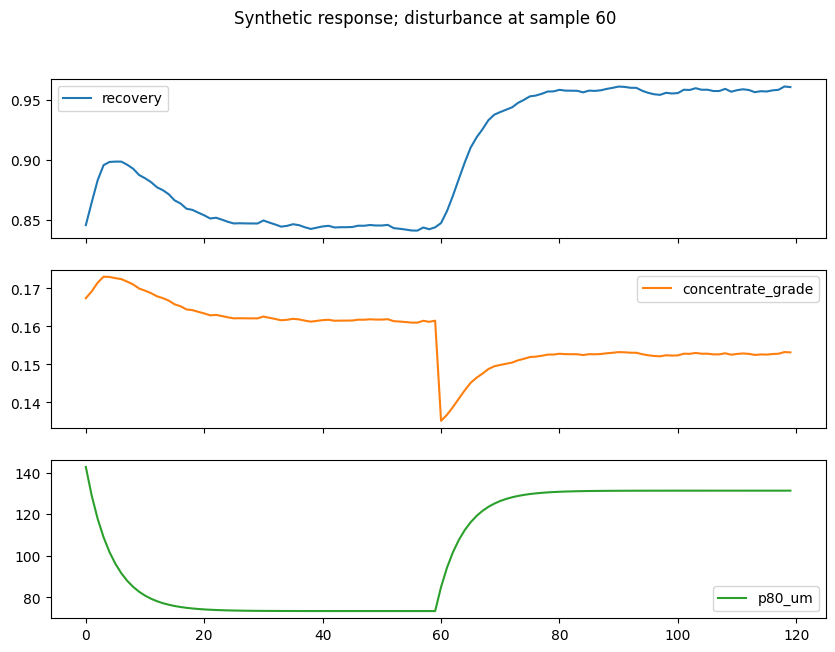

In [6]:
trajectory[["recovery", "concentrate_grade", "p80_um"]].plot(
    subplots=True, figsize=(10, 7), title="Synthetic response; disturbance at sample 60"
)

## 4. Reproducible sensor degradation

<Axes: title={'center': 'Injected sensor drift'}>

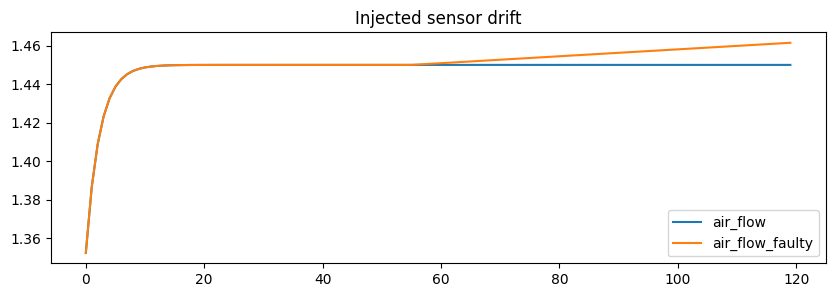

In [7]:
from mineral_process.simulation.sensor_faults import FaultSpec, FaultType, inject_fault

signal = trajectory["air_flow"].to_numpy()
trajectory["air_flow_faulty"] = inject_fault(signal, FaultSpec(FaultType.DRIFT, 55, 1.0), seed=42)
trajectory[["air_flow", "air_flow_faulty"]].plot(figsize=(10, 3), title="Injected sensor drift")

## Exercise

Increase throughput to 145 t/h after the disturbance. Compare P80, recovery and specific energy.
Why is a throughput change not a free improvement?

In [8]:
# Answer scaffold
exercise_plant = SyntheticMineralPlant(seed=42)
exercise_plant.inject_disturbance(hardness=23)
high_throughput = PlantAction(1.45, 0.58, 10.1, 35, 145)
answer = pd.DataFrame(exercise_plant.run(60, high_throughput))
answer[["throughput_tph", "p80_um", "recovery", "specific_energy_kwh_t"]].tail(1)

,throughput_tph,p80_um,recovery,specific_energy_kwh_t
59,144.999999,198.180423,0.863052,12.758621


## Pitfall and extension

**Pitfall:** treating normalized air flow or a simulator-safe bound as a real setpoint. Units and
calibration are plant-specific. **Extension:** calibrate kinetics using a documented laboratory
campaign and propagate parameter uncertainty.